# Tutorial 12: Raw and Processed Data Visualization

As mentioned before, raw and processed images, as well as line profiles and simulated peaks, can be visualized using the `pygid.Conversion` class. This tutorial demonstrates how to change the default plotting parameters.

In [3]:
from scipy.stats import reciprocal

from pygid.datasets import get_dataset

# Download example dataset from Zenodo
try:
    files = get_dataset("tutorial_03")
    poni_path = files["poni_for_tiff"]
    # several files for batch processing
    data_path = files["data1_tiff"]
except:
    print("Dataset download skipped on Read the Docs.")

Load the PONI file, raw data and create the `pygid.CoordMaps` instance.

In [14]:
import pygid

params = pygid.ExpParams(
    poni_path=poni_path,          # path to the PONI file
    ai=0.01,                       # angle of incidence (degrees)
    flipud=True
)

matrix = pygid.CoordMaps(
    params  # pygid.ExpParams
)

analysis = pygid.Conversion(
    matrix=matrix,                   # pygid.CoordMaps
    path=data_path                 # path to the raw data file
)

### Visualization of Raw Images

Plot images in detector pixel positions (0,0 = direct beam).
#### Parameters

- `frame_num` – frame to plot (int)
- `clims` – `(vmin, vmax)` for color scale
- `return_result` – return `(x, y, img)` if `True`
- `plot_result` – display the plot (`True`/`False`)
- `xlim`, `ylim` – axis limits, e.g., `(0, 500)`
- `save_fig` – save the figure (`True`/`False`)
- `path_to_save_fig` – path to save figure, default `"img.png"`


Plot the raw image with default parameters:

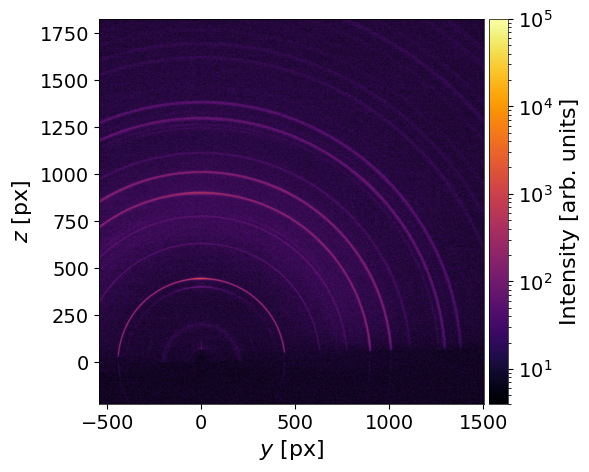

In [15]:
analysis.plot_img_raw(frame_num=0, clims=(4,1e5))

### Visualization of Converted Images

#### Parameters

- `frame_num` – frame to plot (int)
- `clims` – `(vmin, vmax)` for color scale
- `return_result` – return `(x, y, img)` if `True`
- `plot_result` – display the plot (`True`/`False`)
- `xlim`, `ylim` – axis limits, e.g., `(0, 500)`
- `save_fig` – save the figure (`True`/`False`)
- `path_to_save_fig` – path to save figure, default `"img.png"`


Convert the data to reciprocal space and plot the result with default parameters:

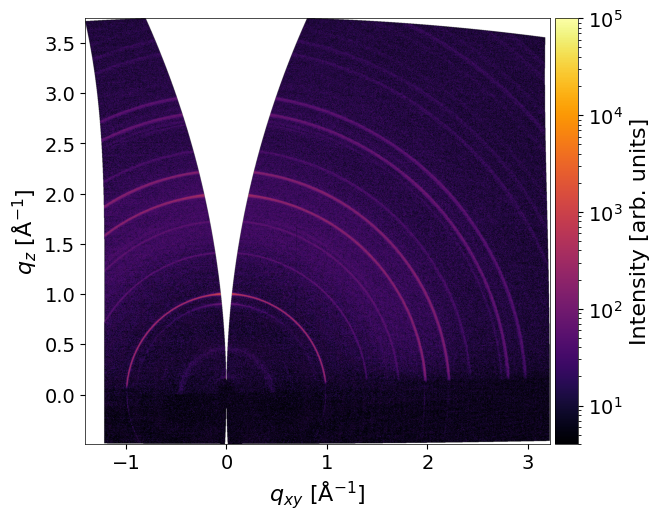

In [21]:
analysis.det2q_gid(plot_result=True, clims=(4,1e5))

or separately

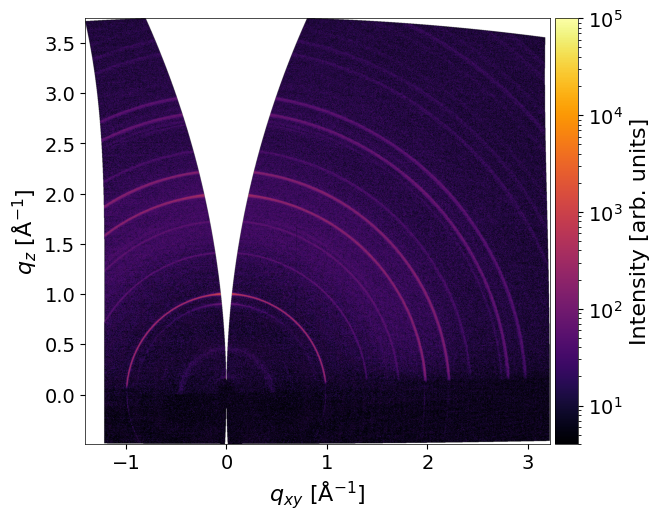

In [23]:
analysis.det2q_gid(plot_result=False)
analysis.plot_result(clims=(4,1e5))

### Change the default plotting parameters using `set_plot_defaults` function:

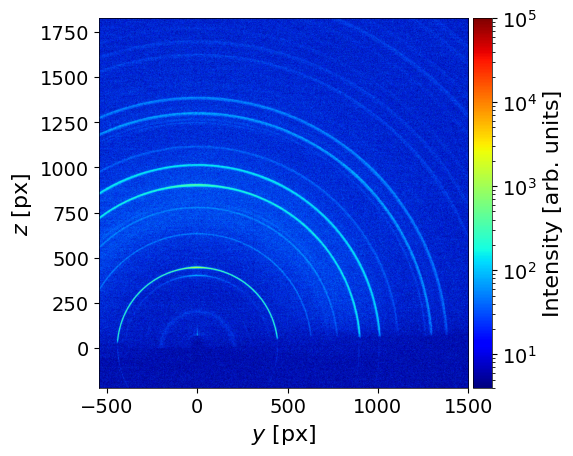

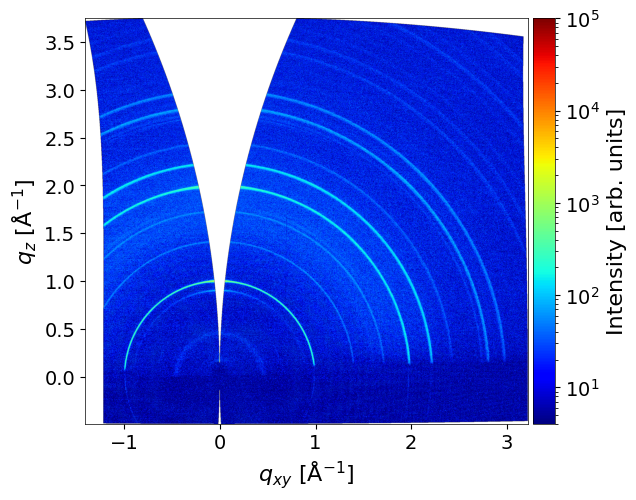

In [33]:
analysis.set_plot_defaults(cmap = 'jet')
analysis.plot_img_raw(frame_num=0, clims=(4,1e5))
analysis.plot_result(clims=(4,1e5))

Full list of adjustable parameters in `set_plot_defaults`

In [34]:
help(analysis.set_plot_defaults)

Help on method set_plot_defaults in module pygid.conversion:

set_plot_defaults(font_size=14, axes_titlesize=None, axes_labelsize=None, grid=False, grid_color='gray', grid_linestyle='--', grid_linewidth=0.5, xtick_labelsize=None, ytick_labelsize=None, legend_fontsize=None, legend_loc='best', legend_frameon=True, legend_borderpad=1.0, legend_borderaxespad=1.0, figure_titlesize=None, figsize=(6.4, 4.8), axes_linewidth=0.5, savefig_dpi=600, savefig_transparent=False, savefig_bbox_inches=None, savefig_pad_inches=0.1, line_linewidth=2, line_color='blue', line_linestyle='-', line_marker=None, scatter_marker='o', scatter_edgecolors='black', cmap='inferno') class method of pygid.conversion.Conversion
    Sets the default settings for various parts of a Matplotlib plot, including font sizes, gridlines,
    legend, figure properties, and line styles. The function configures the default style for future
    plots created with Matplotlib.

    Parameters:
    - font_size (int): Default font size f

The default font size is **14 pt**. By default, `xtick_labelsize` and `ytick_labelsize` are set to `font_size`, while `axes_labelsize` is set to `font_size + 2`. To override these defaults, specify `xtick_labelsize`, `ytick_labelsize`, and `axes_labelsize` explicitly.

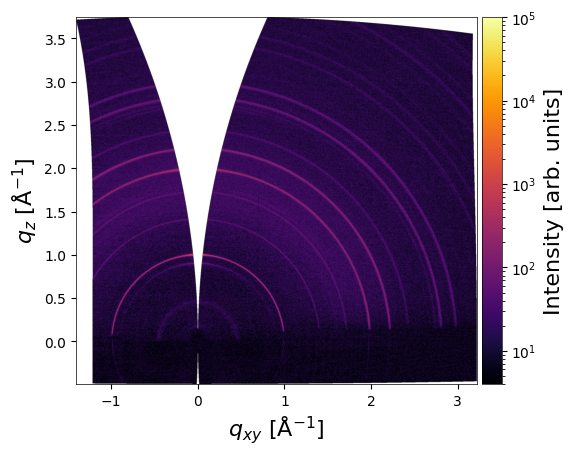

In [35]:
analysis.set_plot_defaults(figsize=(5,5), xtick_labelsize=10, ytick_labelsize=10, axes_labelsize=16)
analysis.plot_result(clims=(4,1e5))